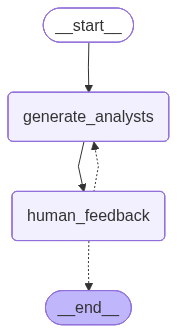


=== FIRST RUN (Analyst Generation + HITL Pause) ===

{'topic': 'Langchain ecosystem', 'analysts': [Analyst(name='Dr. Lena Smith', specialty='LLM Application Architect', description='Dr. Smith specializes in designing and implementing complex AI applications using the Langchain framework. Her expertise includes prompt engineering, agentic systems, and integrating various LLMs for enterprise solutions.'), Analyst(name='Alex Chen', specialty='Data Integration Specialist', description='Alex focuses on connecting Langchain applications with diverse data sources and APIs. He is adept at building custom data loaders, document transformers, and ensuring seamless data flow within Langchain-powered systems.'), Analyst(name='Maria Rodriguez', specialty='AI Ethics and Governance Consultant', description='Maria advises on the responsible development and deployment of Langchain applications. Her work involves evaluating bias, ensuring transparency, and establishing governance frameworks for AI solu

In [ ]:
import operator
from typing import Annotated, List, Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain.prompts import PromptTemplate
from pydantic import BaseModel
from langchain_core.messages import HumanMessage
from langgraph.types import interrupt, Command
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


class Analyst(BaseModel):
    name: str
    specialty: str
    description: str


class AnalystOutput(BaseModel):
    analysts: List[Analyst]


class ResearchState(BaseModel):
    topic: str
    analysts: List[Analyst] = []
    feedback: str = ""
    tasks: list[str] = []
    research_outputs: Annotated[list[str], operator.add] = []


def generate_analysts(state: ResearchState):
    prompt = PromptTemplate(
        template=(
            "You are an analyst generator. "
            "Generate 3-4 analyst profiles for the topic: {topic}. "
            "Return ONLY structured JSON for: name, specialty, description."
        ),
        input_variables=["topic"],
    )

    prompt_text = prompt.format(topic=state.topic)
    structured_llm = llm.with_structured_output(AnalystOutput)

    result = structured_llm.invoke([HumanMessage(content=prompt_text)])
    return {"analysts": result.analysts}


def human_feedback(state: ResearchState):
    fb = interrupt("Review the analysts. Enter 'approve' OR 'regenerate':")
    return {"feedback": fb}


def need_regeneration(state: ResearchState) -> Literal["generate_analysts", END]:  # type: ignore
    print("COMING HEREEEE=>>>>")
    fb = state.feedback.lower().strip()

    if fb == "approve":
        return END

    if fb == "regenerate":
        return "generate_analysts"

    return "generate_analysts"


memory = MemorySaver()
builder = StateGraph(ResearchState)

builder.add_node("generate_analysts", generate_analysts)
builder.add_node("human_feedback", human_feedback)

builder.add_edge(START, "generate_analysts")
builder.add_edge("generate_analysts", "human_feedback")

builder.add_conditional_edges("human_feedback", need_regeneration)

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


thread = {"configurable": {"thread_id": "chat_1"}}

print("\n=== FIRST RUN (Analyst Generation + HITL Pause) ===\n")
result = graph.invoke({"topic": "Langchain ecosystem"}, config=thread)
print(result)


print("\n=== SECOND RUN (User Input: regenerate) ===\n")
result = graph.invoke(Command(resume="regenerate"), config=thread)
print(result)

print("\n=== THIRD RUN (User Input: approve) ===\n")
result = graph.invoke(Command(resume="approve"), config=thread)
print(result)